In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("/content/Unemployment in India.csv")

# Display first 5 rows
print("FIRST 5 ROWS OF DATASET:\n")
print(df.head())

FIRST 5 ROWS OF DATASET:

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


In [3]:
print("\nDATASET INFORMATION:\n")
print(df.info())

print("\nMISSING VALUES:\n")
print(df.isnull().sum())


DATASET INFORMATION:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None

MISSING VALUES:

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unempl

In [4]:
df.columns = df.columns.str.strip()

print("\nCOLUMN NAMES:\n")
print(df.columns)



COLUMN NAMES:

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [5]:
df.dropna(inplace=True)

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Check cleaned data
print("\nCLEANED DATA:\n")
print(df.head())



CLEANED DATA:

           Region       Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh 2019-05-31   Monthly                             3.65   
1  Andhra Pradesh 2019-06-30   Monthly                             3.05   
2  Andhra Pradesh 2019-07-31   Monthly                             3.75   
3  Andhra Pradesh 2019-08-31   Monthly                             3.32   
4  Andhra Pradesh 2019-09-30   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  


In [6]:
print("\nSTATISTICAL SUMMARY:\n")
print(df.describe())


STATISTICAL SUMMARY:

                                Date  Estimated Unemployment Rate (%)  \
count                            740                       740.000000   
mean   2019-12-12 18:36:58.378378496                        11.787946   
min              2019-05-31 00:00:00                         0.000000   
25%              2019-08-31 00:00:00                         4.657500   
50%              2019-11-30 00:00:00                         8.350000   
75%              2020-03-31 00:00:00                        15.887500   
max              2020-06-30 00:00:00                        76.740000   
std                              NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  
count        7.400000e+02                               740.000000  
mean         7.204460e+06                                42.630122  
min          4.942000e+04                                13.330000  
25%          1.190404e+06                  

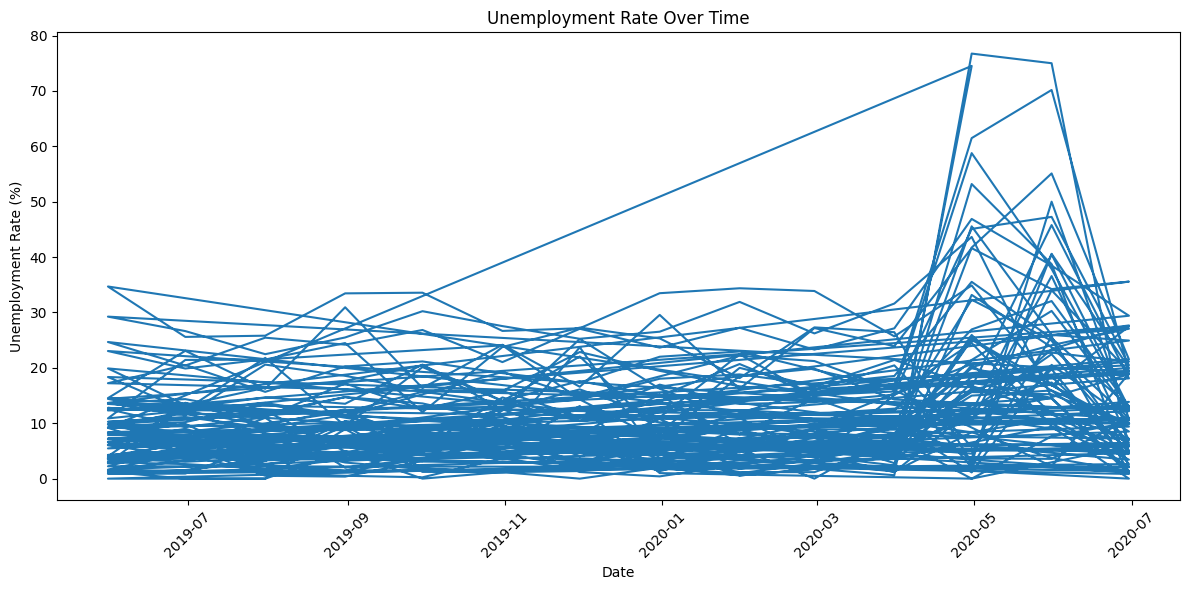

In [7]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Estimated Unemployment Rate (%)'])

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


AVERAGE UNEMPLOYMENT RATE BY YEAR:

Year
2019     9.399047
2020    15.101581
Name: Estimated Unemployment Rate (%), dtype: float64


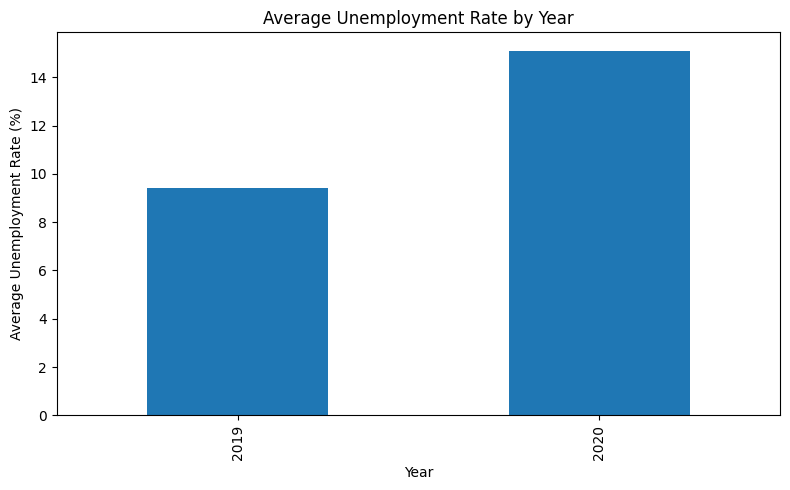

In [8]:
df['Year'] = df['Date'].dt.year

# Average unemployment rate by year
yearly_unemployment = df.groupby('Year')[
    'Estimated Unemployment Rate (%)'
].mean()

print("\nAVERAGE UNEMPLOYMENT RATE BY YEAR:\n")
print(yearly_unemployment)

# Bar chart
plt.figure(figsize=(8,5))

yearly_unemployment.plot(kind='bar')

plt.title("Average Unemployment Rate by Year")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()


STATE WISE UNEMPLOYMENT:

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


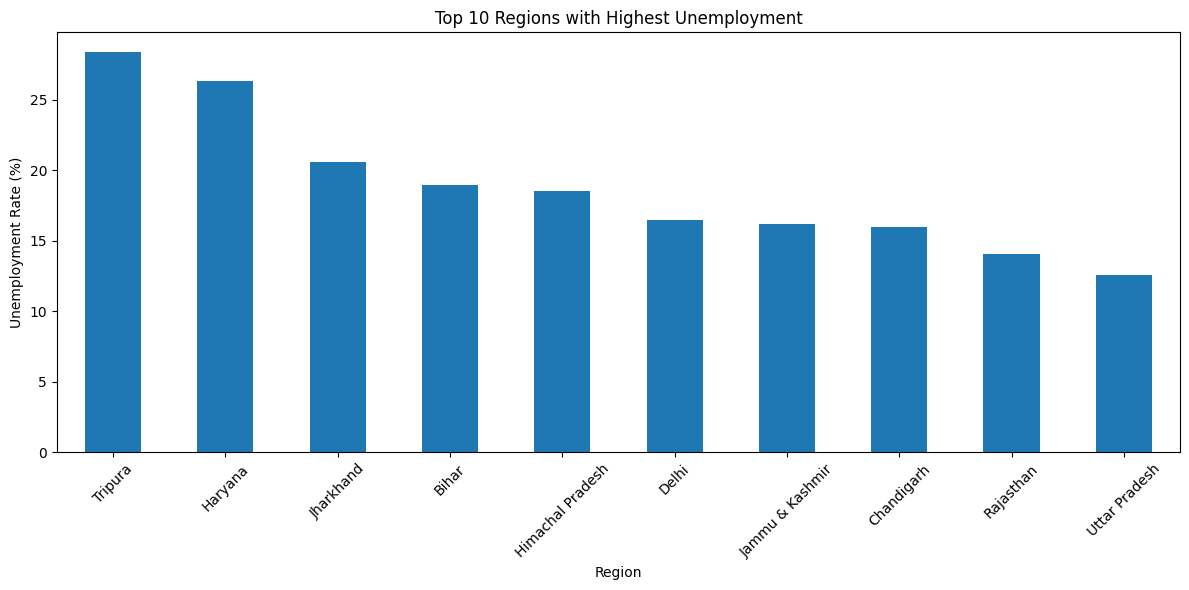

In [9]:
state_unemployment = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False)

print("\nSTATE WISE UNEMPLOYMENT:\n")
print(state_unemployment)

# Top 10 states
plt.figure(figsize=(12,6))

state_unemployment.head(10).plot(kind='bar')

plt.title("Top 10 Regions with Highest Unemployment")
plt.xlabel("Region")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

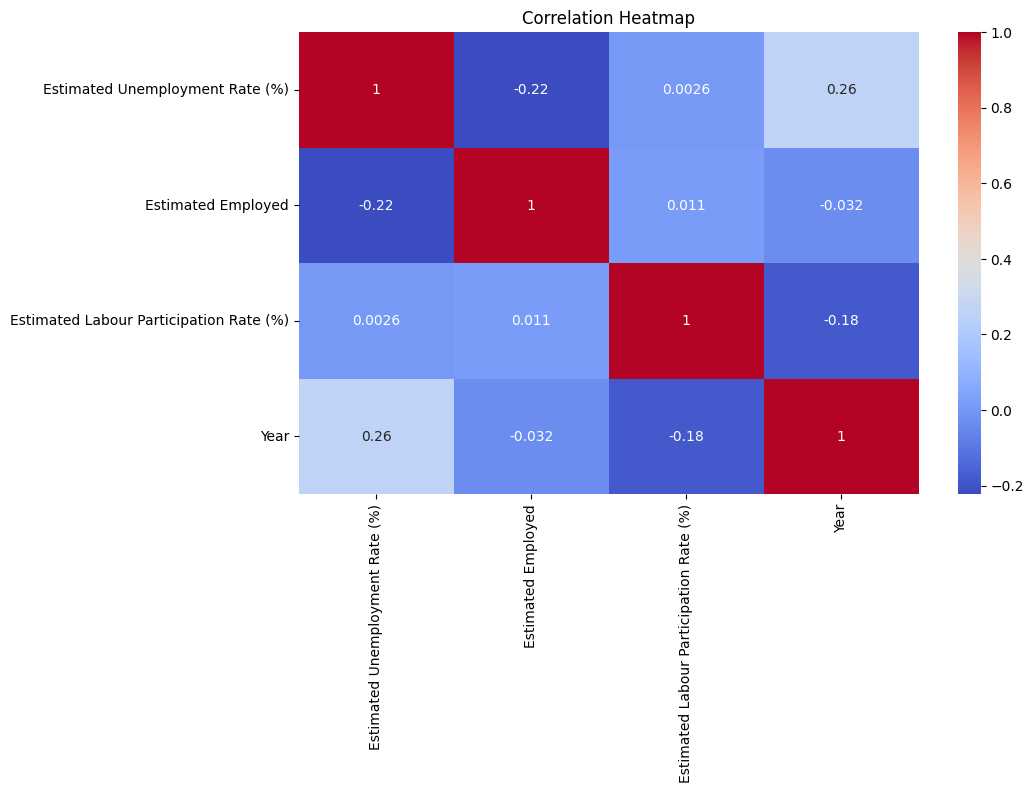

In [10]:

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()


MONTHLY UNEMPLOYMENT TREND:

Month
April        23.641569
August        9.637925
December      9.497358
February      9.964717
January       9.950755
July          9.033889
June         10.553462
March        10.700577
May          16.646190
November      9.868364
October       9.900909
September     9.051731
Name: Estimated Unemployment Rate (%), dtype: float64


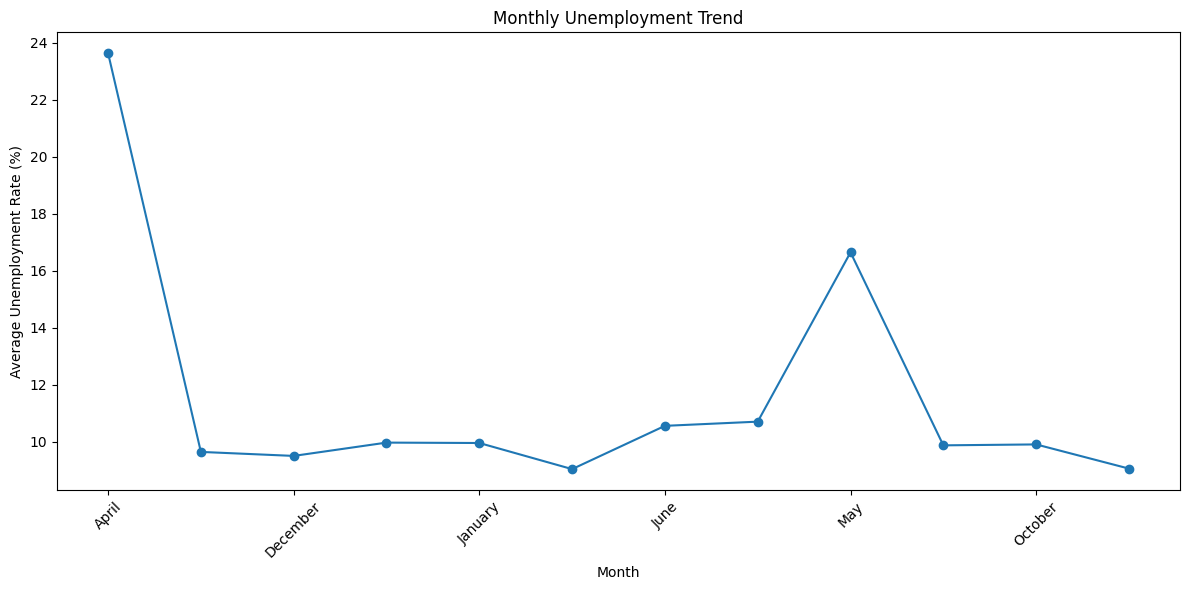

In [11]:

df['Month'] = df['Date'].dt.month_name()

monthly_trend = df.groupby('Month')[
    'Estimated Unemployment Rate (%)'
].mean()

print("\nMONTHLY UNEMPLOYMENT TREND:\n")
print(monthly_trend)

# Plot monthly trends
plt.figure(figsize=(12,6))

monthly_trend.plot(kind='line', marker='o')

plt.title("Monthly Unemployment Trend")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [12]:

print("\n======================================")
print("KEY INSIGHTS")
print("======================================")

print("""
1. Unemployment rates increased significantly during Covid-19.

2. Certain regions experienced much higher unemployment than others.

3. Monthly trends show fluctuations indicating seasonal employment effects.

4. Covid-19 had a major economic impact across multiple sectors.

5. Data analysis can help governments create employment policies.
""")



KEY INSIGHTS

1. Unemployment rates increased significantly during Covid-19.

2. Certain regions experienced much higher unemployment than others.

3. Monthly trends show fluctuations indicating seasonal employment effects.

4. Covid-19 had a major economic impact across multiple sectors.

5. Data analysis can help governments create employment policies.

